# Домашнее задание «Линейный классификатор и логистическая регрессия»

## 1. Загрузка данных

Загрузите датасет в Python с помощью библиотеки pandas.

Необходимо:
* посмотреть первые строки таблицы
* определить размер датасета
* проверить названия колонок
* убедиться, что целевая переменная загружена корректно.

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [5]:
df = pd.read_csv('Bank Customer Churn Prediction.csv')
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
print(f'Размерность анализируемого датасета: {df.shape}')

Размерность анализируемого датасета: (10000, 12)


In [7]:
# названия столбцов (лишних пробелов нет)
df.columns

Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_card', 'active_member',
       'estimated_salary', 'churn'],
      dtype='object')

In [8]:
# проверка корректности столбца с целевой переменной
print(f'Тип данных столбца целевой переменной: {df['churn'].dtype}')
print(f'Уникальные значения целевой переменной: {df['churn'].unique()}')

Тип данных столбца целевой переменной: int64
Уникальные значения целевой переменной: [1 0]


*Проблем с названиями столбцов нет, лишних пробелов нет.
Целевая переменная загружена корректно: имеет числовой тип данных, значения корректны (0 или 1)*

## 2. Первичный анализ данных

Проведите базовый анализ данных.

Необходимо:
* посмотреть типы данных (`info()`)
* изучить статистику числовых признаков (`describe()`)
* проверить распределение целевой переменной
* проверить наличие пропущенных значений
* проверить наличие дубликатов

In [9]:
# типы данных в столбцах датафрейма
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [10]:
# статистика числовых признаков
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [11]:
# распределение значений целевой переменной
df['churn'].value_counts()

,count
churn,
0,7963
1,2037


In [12]:
# проверка на пропуски
print('Процент пропусков в столбцах анализируемого датафрейма:\n')
df.isna().mean()*100

Процент пропусков в столбцах анализируемого датафрейма:



,0
customer_id,0.0
credit_score,0.0
country,0.0
gender,0.0
age,0.0
tenure,0.0
balance,0.0
products_number,0.0
credit_card,0.0
active_member,0.0


In [13]:
# проверка на дубликаты
print(df[df.duplicated(keep=False)])
print(f'\nКоличество дубликатов: {df.duplicated().sum()}')

Empty DataFrame
Columns: [customer_id, credit_score, country, gender, age, tenure, balance, products_number, credit_card, active_member, estimated_salary, churn]
Index: []

Количество дубликатов: 0


*Все столбцы имеют верные по смыслу типы данных. Пропусков в данных и дубликатов строк нет.*

## 3. Разведочный анализ данных (EDA)

Изучите распределение признаков и их связь с оттоком клиентов.

Постройте:
* график распределения целевой переменной
* гистограммы числовых признаков
* boxplot для возраста и баланса относительно churn
* корреляционную матрицу признаков

Сделайте краткие выводы: какие признаки могут быть связаны с оттоком клиентов. Пропишите свои выводы в ноутбуке.

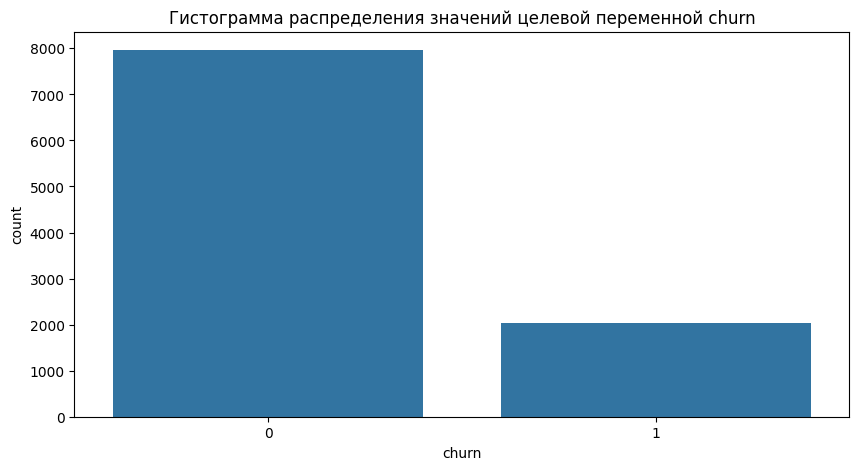

In [14]:
# распределение целевой переменной
plt.figure(figsize=(10,5))

sns.countplot(x='churn', data=df)

plt.title('Гистограмма распределения значений целевой переменной churn')
plt.show()

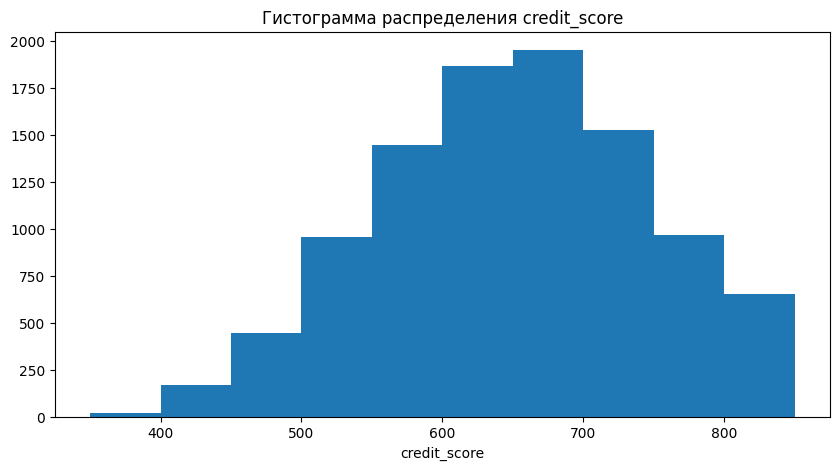

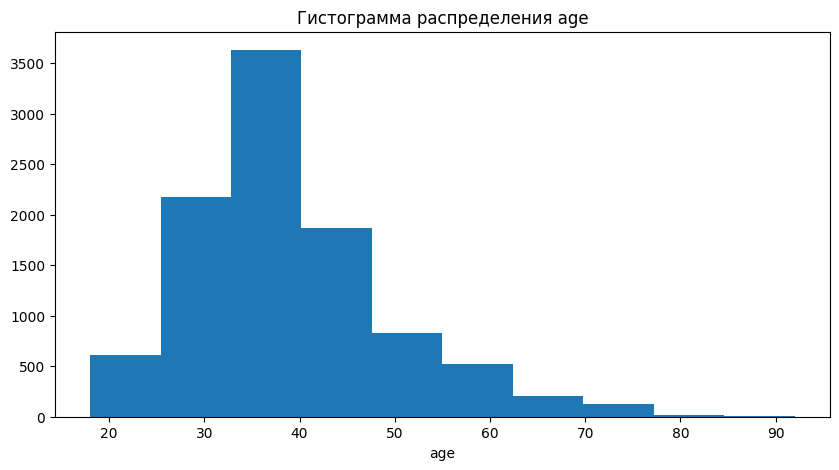

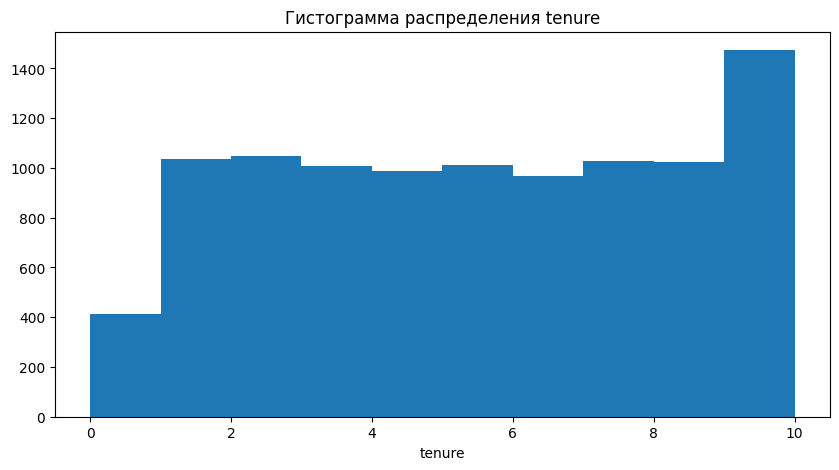

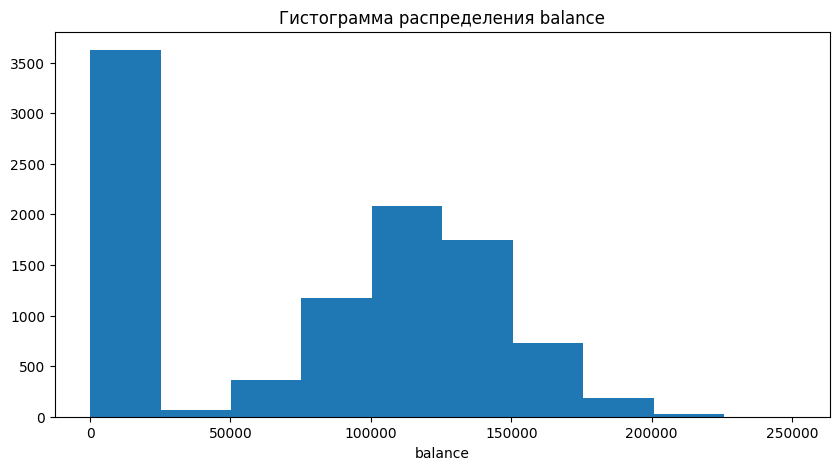

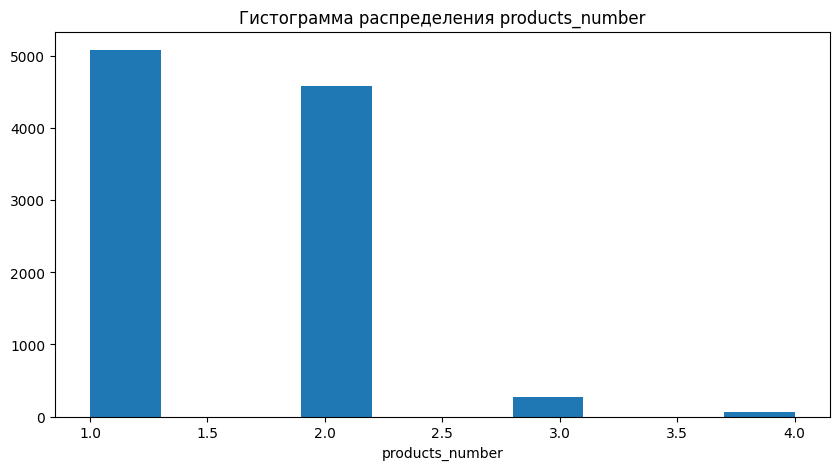

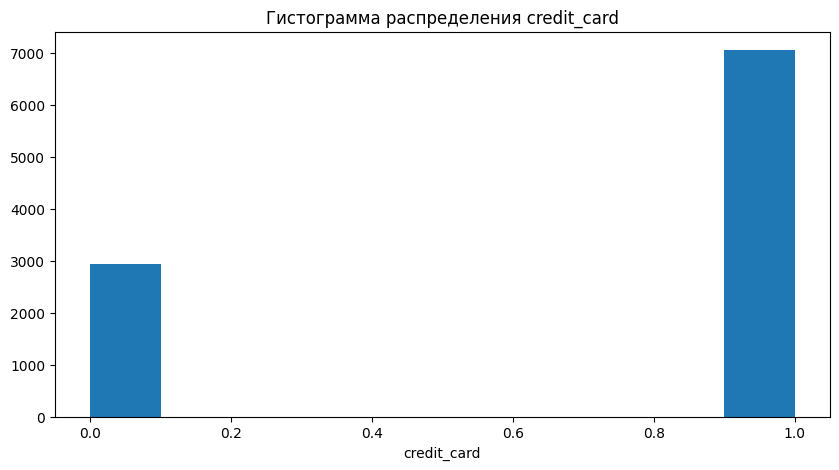

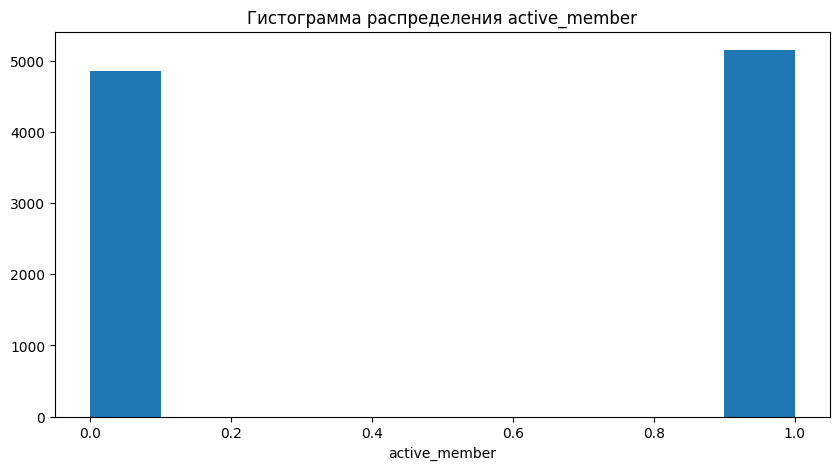

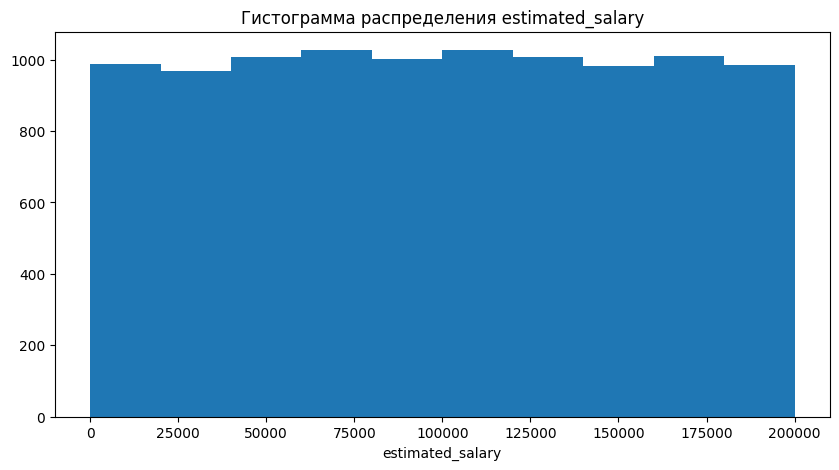

In [15]:
# гистограммы числовых признаков
num_cols = list(df.select_dtypes(include='number').columns)
num_cols.remove('customer_id')
num_cols.remove('churn')

for col in num_cols:
    plt.figure(figsize=(10,5))
    plt.hist(df[col])
    plt.xlabel(col)
    plt.title(f'Гистограмма распределения {col}')
    plt.show()
    print()

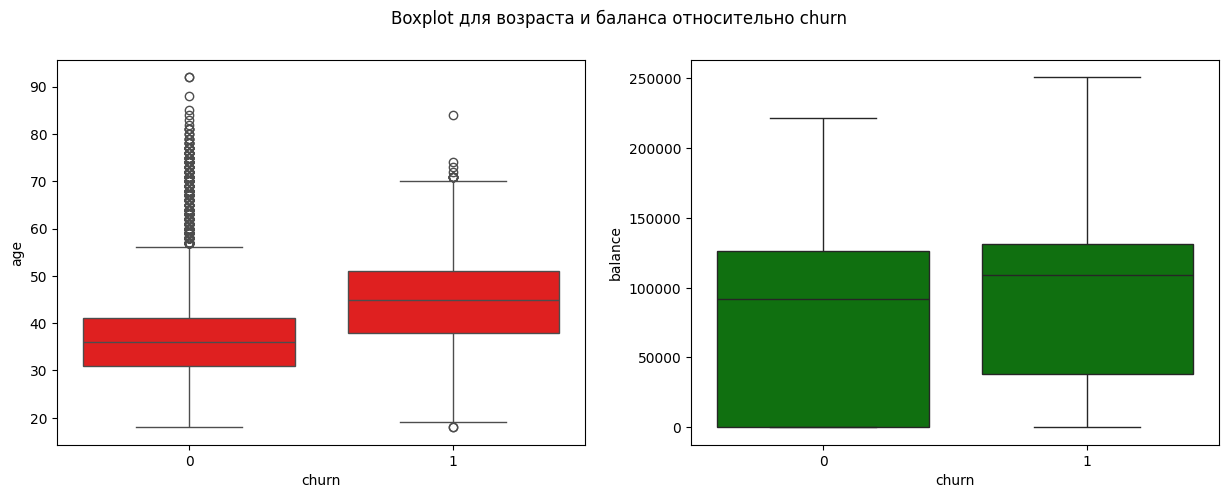

In [16]:
# boxplot для возраста и баланса относительно churn
fig, axes = plt.subplots(1, 2, figsize=(15,5))
fig.suptitle('Boxplot для возраста и баланса относительно churn')

sns.boxplot(x='churn', y='age', data=df, color='red', ax=axes[0])
sns.boxplot(x='churn', y='balance', data=df, color='green', ax=axes[1])

plt.show()

<Axes: >

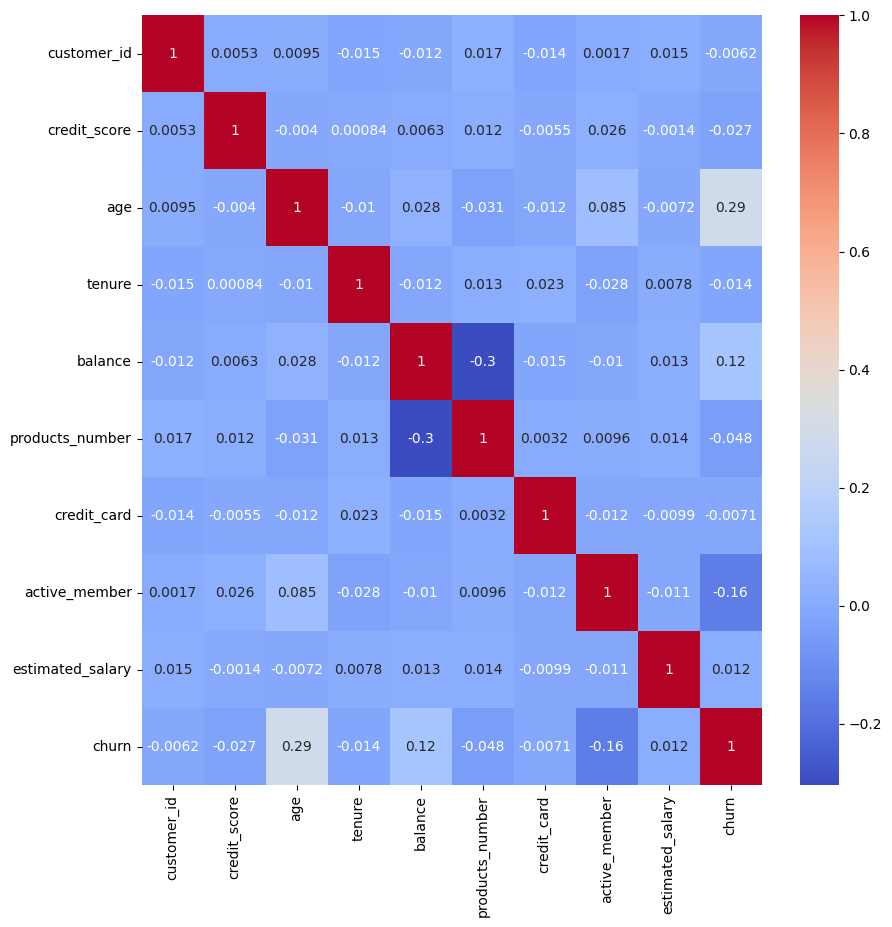

In [17]:
# корреляционная матрица числовых признаков
corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

*С оттоком клиентом наиболее вероятно могут быть связаны признаки `age`, `balance`, `product_number`, `active_member`. Boxplot показали, что имеются заметные различия распределений возраста и баланса между оставшимися и ушедшими клиентами. По корреляционной матрице сильных линейных зависимостей признаков с целевой переменной не обнаружено, лишь только `age` близок к умеренной корреляции.*

## 4. Предобработка и разделение данных

Разделите данные на:
* обучающую выборку (80%)
* тестовую выборку (20%)

Используйте функцию `train_test_split`

Подготовьте данные для обучения модели.

Необходимо:
* удалить столбцы, которые вы считаете не нужными для обучения модели. Свой выбор аргументируйте в файле ноутбука
* закодировать категориальные признаки (`country`, `gender`) с помощью `One-Hot Encoding`
* масштабировать числовые признаки с помощью `StandardScaler`
* сформировать итоговый набор признаков

In [18]:
# целевая переменная
y = df['churn']

# признаки
# удаляем целевую переменную и ненужные для обучения столбцы
X = df.drop(columns=['customer_id', 'churn'])

*Удален столбец `customer_id` с идентификаторами клиентов, который не несет никакой информации для модели. Все остальные столбцы полезны в той или иной степени.*

In [19]:
# определим категориальные признаки
cat_cols = ['country', 'gender']

In [20]:
# числовые признаки были определены ранее
num_cols

['credit_score',
 'age',
 'tenure',
 'balance',
 'products_number',
 'credit_card',
 'active_member',
 'estimated_salary']

In [21]:
# разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [22]:
# предобработка признаков: кодирование категориальных и масштабирование числовых
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ]
    )

In [23]:
# pipeline предобработки и обучения
log_regr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=3000, random_state=42))
    ])

## 5. Обучение модели

Обучите модель Logistic Regression.

После обучения:
* получите предсказания модели на тестовой выборке

In [24]:
# обучение модели
log_regr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['credit_score', 'age',
                                                   'tenure', 'balance',
                                                   'products_number',
                                                   'credit_card',
                                                   'active_member',
                                                   'estimated_salary']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['country', 'gender'])])),
                ('model', LogisticRegression(max_iter=3000, random_state=42))])

In [25]:
# предсказания
# классов
y_pred = log_regr_pipeline.predict(X_test)
# вероятностей положительного класса
y_pred_proba = log_regr_pipeline.predict_proba(X_test)[:, 1]

## 6. Оценка качества модели

Оцените качество модели с помощью следующих метрик:

* Accuracy
* Precision
* Recall
* F1-score
* ROC-AUC
* Также постройте Confusion Matrix

Сделайте вывод о качестве модели — пропишите вывод в ноутбуке.

In [26]:
print('Метрики качества модели:')
print(f'Accuracy: ------ {accuracy_score(y_test, y_pred):.4f}')
print(f'Precision: ----- {precision_score(y_test, y_pred):.4f}')
print(f'Recall: -------- {recall_score(y_test, y_pred):.4f}')
print(f'F1-score: ------ {f1_score(y_test, y_pred):.4f}')
print(f'ROC-AUC: ------- {roc_auc_score(y_test, y_pred_proba):.4f}')

Метрики качества модели:
Accuracy: ------ 0.8080
Precision: ----- 0.5891
Recall: -------- 0.1867
F1-score: ------ 0.2836
ROC-AUC: ------- 0.7748


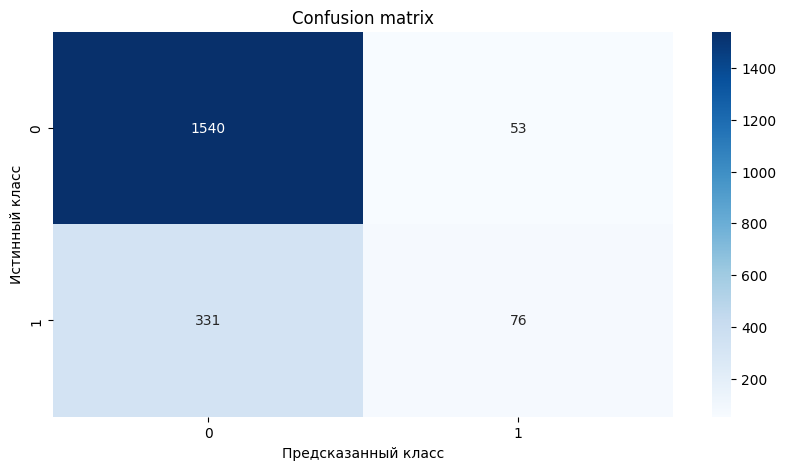

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Confusion matrix')

plt.show()

*Модель логистической регрессии показала удовлетворительное качество классификации `ROC_AUC = 0.7748`: она достаточно хорошо различает клиентов, склонных и не склонных к уходу. При этом высока точность `Accuracy = 0.8080` сочетается с низким `Recall = 0.1867`, это показатель того, что модель пропускает значительную часть клиентов, которые действительно уходят.*

## 7. Интерпретация результатов

Проанализируйте результаты модели.

Необходимо:
* определить наиболее важные признаки
* построить график важности признаков
* сделать вывод, какие факторы сильнее всего влияют на отток клиентов.

In [28]:
# получение названий признаков ColumnTransformer и коэффициентов модели
feature_names = log_regr_pipeline['preprocessor'].get_feature_names_out()
coefficients = log_regr_pipeline['model'].coef_[0]

# определение наиболее важных признаков по коэффициентам (весам) модели
coef_df = pd.DataFrame({
    'feature' : feature_names,
    'coefficient' : coefficients
})

coef_df['abs_coef'] = coef_df['coefficient'].abs()

coef_df = coef_df.sort_values(by='abs_coef', ascending=False)
coef_df.head(5)

,feature,coefficient,abs_coef
1,num__age,0.739223,0.739223
12,cat__gender_Male,-0.682052,0.682052
8,cat__country_France,-0.569897,0.569897
10,cat__country_Spain,-0.523565,0.523565
6,num__active_member,-0.515791,0.515791


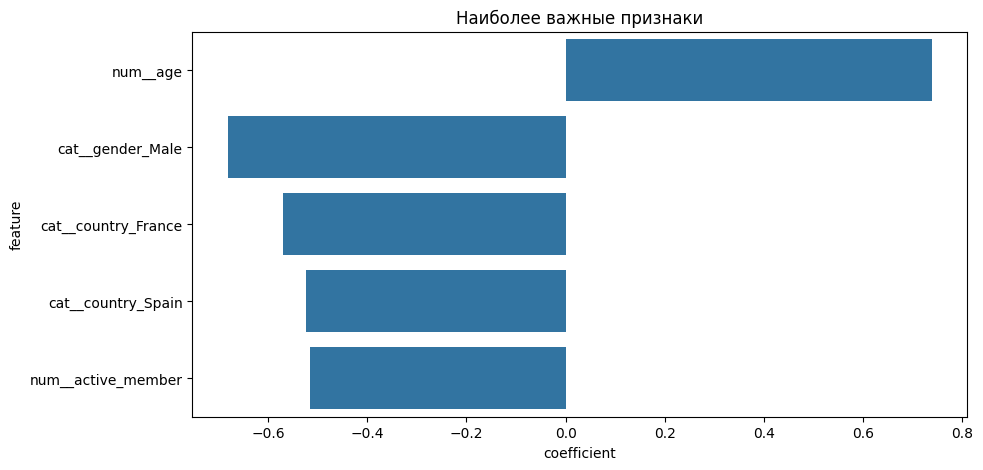

In [29]:
# график важности признаков
plt.figure(figsize=(10,5))

sns.barplot(data=coef_df.head(5), x='coefficient', y='feature')

plt.title('Наиболее важные признаки')
plt.show()

*Выводы по результатам модели:*
* По результатам определения наиболее важных коэффициентов видим, что наибольшее влияние на решение модели на самом деле оказывают следующие признаки: `age`, `gender_Male`, `country_France`, `country_Spain` и `active_member`.
* Положительный коэффициент признака `age` говорит о том, что более высокий возраст клиента связан с увеличением вероятности его ухода.
* Отрицательные же коэффициенты признаков `gender_Male` и `active_member` указывают на то, что мужчины и активные клиенты реже уходят из банка. Коэффициенты категориальных признаков страны следует интерпретировать с учётом способа `One-Hot Encoding`.
* Наиболее значимые факторы модели - это возраст и пол клиента, т.к. они имеют наибольшие по модулю коэффициенты.

## 8. Итоговые выводы

Сформулируйте краткие выводы:
* насколько хорошо модель предсказывает отток клиентов
* какие признаки оказались наиболее важными
* какие улучшения можно внести в модель (например, добавить новые признаки или попробовать другие алгоритмы)

1. По значению `ROC-AUC = 0.7748` можно сделать вывод, что модель показала удовлетворительное качество предсказания оттока клиентов: она хорошо различает клиентов, склонных и не склонных к уходу. При этом низкий `Recall = 0.1867` говорит нам о том, что модель не выявляет значительную часть клиентов, которые действительно уходят из банка.
2. Наиболее важными оказались признаки, связанные со страной, возрастом, полом клиента и его активностью: `age`, `gender_Male`, `country_France`, `country_Spain` и `active_member`.
3. Для повышения качества модели можно попробовать более мощные алгоритмы классификации: `Random Forest`, `Gradient Boosting`. Можно провести инженерию признаков. Например, могут быть полезны производные признаки:
* величина баланса на счете клиента в зависимости от его заработка;
* срок обслуживания клиента относительно его возраста;
* есть ли баланс на счете (то есть нулевой он или нет);
* комбинирование активности с количество продуктов.

    Можно также добавить такие признаки, как:
* количество банковских операций в определенный период (например, в месяц);
* длительность отсутствия активности клиента;
* есть ли отказы по кредитным продуктам, количество отказов;
* и т.п.